<a href="https://colab.research.google.com/github/Pradeep1694/ml-leakage-pipeline-Pradeep/blob/main/Regression_Predicting_Values.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#----------------------Task 1: ---------------------------
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

np.random.seed(42)
n = 50
data = pd.DataFrame({
    "area_sqft": np.random.randint(500, 2500, n),
    "num_bedrooms": np.random.randint(1, 5, n),
    "age_years": np.random.randint(1, 30, n),
    "price": np.random.randint(0, 30, n)
})

data["price_lakshs"] = (
    0.05 * data["area_sqft"] +
    10 * data["num_bedrooms"] -
    0.8 * data["age_years"] +
    np.random.randint(1, 10, n)
)

x = data[["area_sqft", "num_bedrooms","age_years"]]
y = data["price_lakshs"]

model = LinearRegression()
model.fit(x, y)

print("intercept:", model.intercept_)
print("coefficients:", model.coef_)

y_pred = model.predict(x)

print("\nFirst 5 actual vs Predicted:")
for actual, pred in list(zip(y, y_pred))[:5]:
    print(f"Actual: {actual:.2f}, Predicted: {pred:.2f}")

intercept: 2.4962548892291636
coefficients: [ 0.05048652 10.18426862 -0.71444021]

First 5 actual vs Predicted:
Actual: 91.90, Predicted: 92.10
Actual: 114.15, Predicted: 113.38
Actual: 105.40, Predicted: 103.32
Actual: 122.10, Predicted: 122.19
Actual: 120.50, Predicted: 118.38


In [6]:
#---------------------Task 2: -----------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("\nMAE:", mae)
print("\nRMSE:", rmse)
print("R2 Score:", r2)


MAE: 2.3191772868144556

RMSE: 2.659341967734529
R2 Score: 0.9904777194279736


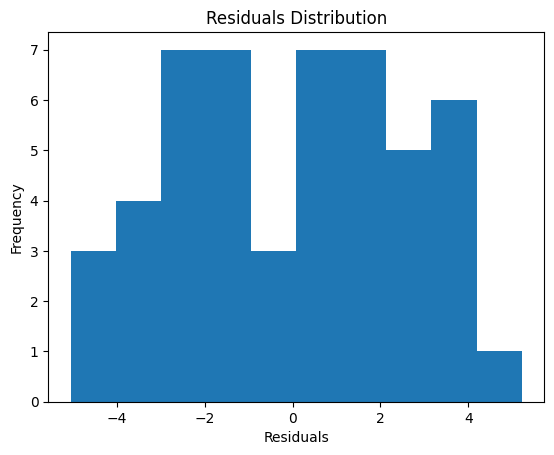

In [7]:
#-------------------Task 3: --------------------
import matplotlib.pyplot as plt

residuals = y - y_pred

plt.hist(residuals)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title("Residuals Distribution")
plt.show()